In [1]:
import nltk
from nltk.corpus import treebank
import statistics
import matplotlib.pyplot as plt
import numpy as np
import re
from transformers import BertTokenizer, BertModel
import torch

# Download and load corpus
nltk.download('treebank')
sentences = treebank.sents()
words = treebank.words()
tagged_words = treebank.tagged_words()

# Remove trace tokens and empty categories
TRACE_TOKEN_PATTERN = re.compile(r'^\*.*\*$|^\*$|^\*-?\d+$|^0$')
def is_valid_token(word, pos_tag=None):
    if pos_tag == '-NONE-':
        return False
    if TRACE_TOKEN_PATTERN.match(word):
        return False
    return True

# Cleaned sentences as strings
cleaned_sentences = []
for sentence in treebank.tagged_sents():
    cleaned_tokens = [word for word, pos in sentence if is_valid_token(word, pos)]
    if cleaned_tokens:
        cleaned_sentences.append(" ".join(cleaned_tokens))

[nltk_data] Downloading package treebank to
[nltk_data]     /Users/larsheijnen/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


In [2]:
present_tags = {'VB', 'VBP', 'VBZ'}
past_tags = {'VBD', 'VBN'}

unlabeled_sentences = []
for sent_idx, sentence in enumerate(treebank.tagged_sents()):
    # Use the same filtering as for cleaned_sentences
    filtered = [(w, t) for w, t in sentence if is_valid_token(w, t)]
    if not filtered:
        continue
    present_count = sum(1 for _, t in filtered if t in present_tags)
    past_count = sum(1 for _, t in filtered if t in past_tags)
    if present_count > past_count:
        label = 0  # present
    elif past_count > present_count:
        label = 1  # past
    else:
        continue  # skip ambiguous or no-verb sentences
    # Use the already cleaned sentence string
    cleaned = " ".join([w for w, t in filtered])
    unlabeled_sentences.append((cleaned, label))

In [3]:
present_count = sum(1 for _, label in unlabeled_sentences if label == 0)
past_count = sum(1 for _, label in unlabeled_sentences if label == 1)
print("Unbalanced data:")
print(f"Present tense sentences: {present_count}")
print(f"Past tense sentences: {past_count}")




# Balance the dataset to have equal number of present and past tense sentences
from random import shuffle
# Separate by label
present = [item for item in unlabeled_sentences if item[1] == 0]
past = [item for item in unlabeled_sentences if item[1] == 1]

# Shuffle for randomness
shuffle(present)
shuffle(past)

# Take the minimum count
min_count = min(len(present), len(past))
balanced_labeled_sentences = present[:min_count] + past[:min_count]
shuffle(balanced_labeled_sentences)  # Shuffle to mix present and past

# Show new counts
print("\nUnbalanced data:")
print(f"Balanced present: {sum(1 for _, l in balanced_labeled_sentences if l == 0)}")
print(f"Balanced past: {sum(1 for _, l in balanced_labeled_sentences if l == 1)}")

Unbalanced data:
Present tense sentences: 1728
Past tense sentences: 1434

Unbalanced data:
Balanced present: 1434
Balanced past: 1434


In [4]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

def get_bert_embeddings_no_padding(texts, batch_size=32):
    """
    Efficiently compute BERT [CLS] embeddings for a list of sentences using batching.
    """
    embeddings = []
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    model.to(device)
    model.eval()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            inputs = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt').to(device)
            outputs = model(**inputs)
            cls_embs = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_embs)
    return np.vstack(embeddings)


balanced_sentences = [sent for sent, label in balanced_labeled_sentences]

y_balanced = np.array([label for sent, label in balanced_labeled_sentences])



X_balanced_sentence_features = get_bert_embeddings_no_padding(balanced_sentences)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced_sentence_features, y_balanced, test_size=0.2, stratify=y_balanced, random_state=42
)

log_reg = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Present', 'Past']))

              precision    recall  f1-score   support

     Present       0.87      0.89      0.88       287
        Past       0.89      0.87      0.88       287

    accuracy                           0.88       574
   macro avg       0.88      0.88      0.88       574
weighted avg       0.88      0.88      0.88       574



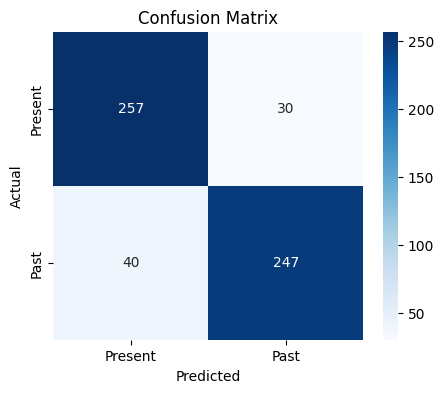

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Present', 'Past'], yticklabels=['Present', 'Past'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()